# Análise Exploratória do Conjunto de Treino

## Importar bibliotecas

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Dataset EDA carregado, total de alunos: 207


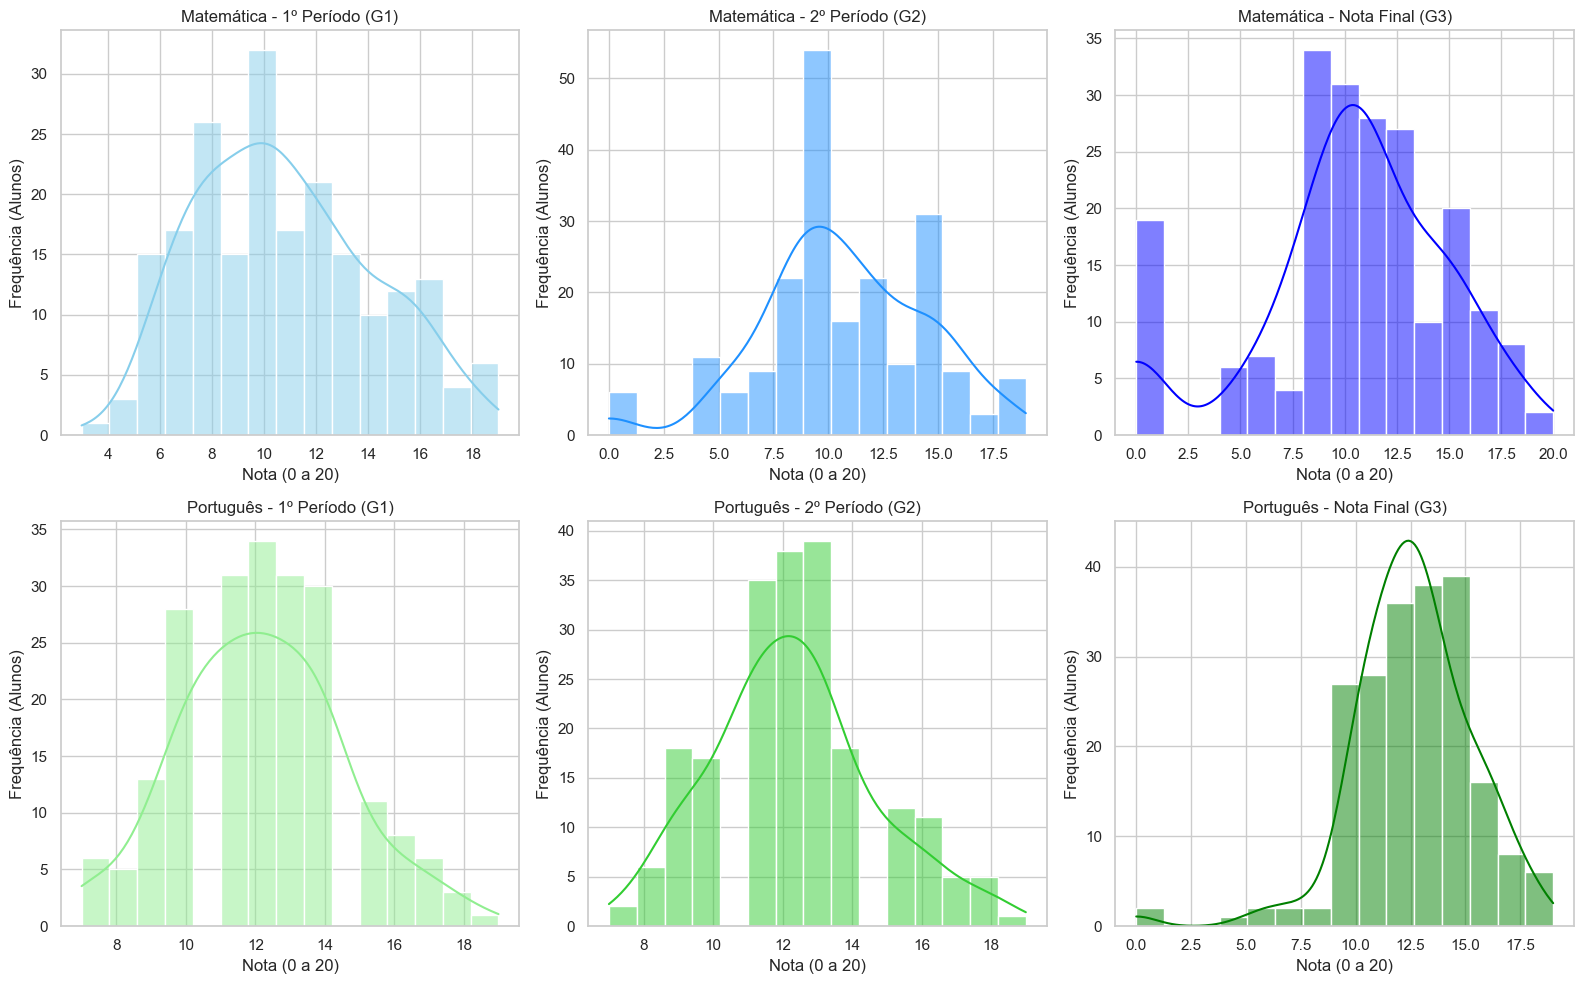

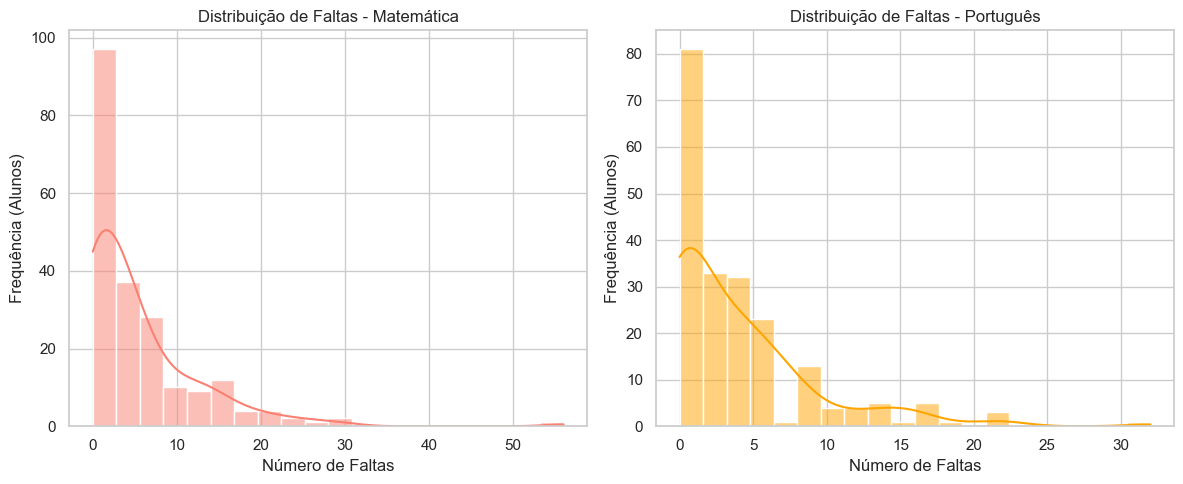

ESTATÍSTICAS DESCRITIVAS: NOTAS E FALTAS (CONJUNTO EDA)
            Média  Moda  Mediana  Desvio Padrão  Mínimo  Máximo
NOTA_1_MAT  10.77    10    10.00           3.32    3.00   19.00
NOTA_2_MAT  10.66    10    10.00           3.77    0.00   19.00
NOTA_3_MAT  10.35    10    11.00           4.55    0.00   20.00
NOTA_1_POR  12.17    12    12.00           2.38    7.00   19.00
NOTA_2_POR  12.29    13    12.00           2.36    7.00   19.00
NOTA_3_POR  12.61    13    13.00           2.72    0.00   19.00
FALTAS_MAT   5.49     0     4.00           7.16    0.00   56.00
FALTAS_POR   3.93     0     2.00           5.11    0.00   32.00


In [8]:
# Carregar dataset EDA da pasta dataset
df_eda = pd.read_csv("../dataset/student-eda.csv")

print(f"Dataset EDA carregado, total de alunos: {len(df_eda)}")

# Configuração de estilo visual para todos os gráficos do notebook
sns.set_theme(style="whitegrid")

# Gráfico de distribuição das notas
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Linha 1: Matemática
sns.histplot(df_eda['NOTA_1_MAT'], bins=15, kde=True, color='skyblue', ax=axes[0, 0])
axes[0, 0].set_title('Matemática - 1º Período (G1)')

sns.histplot(df_eda['NOTA_2_MAT'], bins=15, kde=True, color='dodgerblue', ax=axes[0, 1])
axes[0, 1].set_title('Matemática - 2º Período (G2)')

sns.histplot(df_eda['NOTA_3_MAT'], bins=15, kde=True, color='blue', ax=axes[0, 2])
axes[0, 2].set_title('Matemática - Nota Final (G3)')

# Linha 2: Português
sns.histplot(df_eda['NOTA_1_POR'], bins=15, kde=True, color='lightgreen', ax=axes[1, 0])
axes[1, 0].set_title('Português - 1º Período (G1)')

sns.histplot(df_eda['NOTA_2_POR'], bins=15, kde=True, color='limegreen', ax=axes[1, 1])
axes[1, 1].set_title('Português - 2º Período (G2)')

sns.histplot(df_eda['NOTA_3_POR'], bins=15, kde=True, color='green', ax=axes[1, 2])
axes[1, 2].set_title('Português - Nota Final (G3)')

# Ajustando rótulos para todos os 6 gráficos
for ax in axes.flat:
    ax.set_ylabel('Frequência (Alunos)')
    ax.set_xlabel('Nota (0 a 20)')
    ax.ticklabel_format(style='plain', axis='both')

plt.tight_layout()
plt.show()

# Gráfico de Distribuição de faltas
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Faltas Matemática
sns.histplot(df_eda['FALTAS_MAT'], bins=20, kde=True, color='salmon', ax=axes[0])
axes[0].set_title('Distribuição de Faltas - Matemática')
axes[0].set_xlabel('Número de Faltas')

# Faltas Português
sns.histplot(df_eda['FALTAS_POR'], bins=20, kde=True, color='orange', ax=axes[1])
axes[1].set_title('Distribuição de Faltas - Português')
axes[1].set_xlabel('Número de Faltas')

# Formatando os eixos das faltas
for ax in axes:
    ax.set_ylabel('Frequência (Alunos)')
    ax.ticklabel_format(style='plain', axis='both')

plt.tight_layout()
plt.show()


# Impressão das informações
# Colunas usadas nos gráficos
colunas_analise = [
    'NOTA_1_MAT', 'NOTA_2_MAT', 'NOTA_3_MAT',
    'NOTA_1_POR', 'NOTA_2_POR', 'NOTA_3_POR',
    'FALTAS_MAT', 'FALTAS_POR'
]

# Calcula as estatísticas básicas
estatisticas = df_eda[colunas_analise].describe().T

# Adiciona a Moda (o valor mais frequente)
estatisticas['moda'] = df_eda[colunas_analise].mode().iloc[0]

# Reorganizando a ordem das colunas
ordem_colunas = ['mean', 'moda', '50%', 'std', 'min', 'max']
estatisticas = estatisticas[ordem_colunas]

# Renomeando as colunas
estatisticas.columns = ['Média', 'Moda', 'Mediana', 'Desvio Padrão', 'Mínimo', 'Máximo']

# Formatando para exibir apenas duas casas decimais
pd.set_option('display.float_format', lambda x: '%.2f' % x)

print("="*80)
print("ESTATÍSTICAS DESCRITIVAS: NOTAS E FALTAS (CONJUNTO EDA)")
print("="*80)
print(estatisticas)
print("="*80)